# Buy/Sell Signal Classification + Portfolio Stock Selection
### Binary Conv1D-GRU Meta-Model — Task 3 & Task 4

**Task 3** — Train a signal classifier on a single stock (VNINDEX):
- `1 = Accumulation` — price rises ≥ 1.5% within look-ahead window
- `0 = Distribution` — price falls ≥ 1.5% within look-ahead window

**Task 4** — Apply the trained meta-model to a universe of stocks, evaluate each on a 20-bar horizon, and select those with hit rate > 52%.

**Architecture:** Conv1D feature extractor → stacked GRU → Dense head + rule-score meta-blend

**Pipeline**
1. Feature engineering (HH, LL, AD_slope, EMA9_ratio)
2. Forward-return labelling (neutral bars dropped)
3. Sliding-window construction + per-sample min-max normalisation
4. Chronological train / val / test split
5. Bayesian hyperparameter search (keras-tuner)
6. Final model training
7. Meta-learner: rule-score + GRU probability blend
8. Evaluation: AUC-ROC, F1, confidence analysis
9. **[Task 4]** EDA across stock universe
10. **[Task 4]** Cross-stock inference: avg return, hit rate, profit factor (horizon=20)
11. **[Task 4]** Portfolio optimisation by maximising Sharpe Ratio

---
## 0 — Imports & Shared Constants

In [ ]:
!pip install keras-tuner PyPortfolioOpt -q

import numpy as np
import pandas as pd
import warnings
import os
import pickle
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score, f1_score, accuracy_score,
)
import scipy.stats as stats
from scipy.stats import jarque_bera, kurtosis, skew
from statsmodels.tsa.stattools import adfuller
from scipy.stats import pointbiserialr

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, GRU, Dense, Dropout, BatchNormalization,
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import keras_tuner as kt

from pypfopt import EfficientFrontier, risk_models, expected_returns
from pypfopt.discrete_allocation import DiscreteAllocation

print(f"TensorFlow : {tf.__version__}")
print(f"Keras Tuner: {kt.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 9.8 MB/s eta 0:00:00
TensorFlow : 2.20.0
Keras Tuner: 1.4.8


In [ ]:
# ── Shared constants ──────────────────────────────────────────────────────
TRAIN_DATA_PATH = 'VNG-VNINDEX-History.csv'

WINDOW_SIZE  = 20
HORIZON_T3   = 5        # look-ahead for Task 3 labelling
HORIZON_T4   = 20       # look-ahead for Task 4 signal evaluation
THRESHOLD    = 0.015    # ±1.5% threshold for label assignment
WARMUP_ROWS  = 20

FEATURE_COLS = ['Open', 'High', 'Low', 'Close', 'HH', 'AD_slope', 'EMA9_ratio', 'Volume', 'LL']
PRICE_IDX    = list(range(4))   # Open, High, Low, Close
N_FEATURES   = len(FEATURE_COLS)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

HIT_RATE_MIN = 0.52   # portfolio selection threshold

# ── Task 4 stock universe — local CSV files only ──────────────────────────
STOCK_UNIVERSE = {
    # Vietnamese stocks — medical and banking sectors
    'DHG': 'DHG-VNINDEX-History.csv',
    'DHN': 'DHN-UpcomIndex-History.csv',
    'DBT': 'DBT-VNINDEX-History.csv',
    'DCL': 'DCL-VNINDEX-History.csv',
    'DHD': 'DHD-UpcomIndex-History.csv',
    'DPH': 'DPH-UpcomIndex-History.csv',
    'HDP': 'HDP-UpcomIndex-History.csv',
    'BID': 'BID-VNINDEX-History.csv',
    'VCB': 'VCB-VNINDEX-History.csv',
    'VIB': 'VIB-VNINDEX-History.csv',
    'TCB': 'TCB-VNINDEX-History.csv',
}

print(f"Training stock  : {TRAIN_DATA_PATH}")
print(f"T3 horizon      : {HORIZON_T3} bars")
print(f"T4 horizon      : {HORIZON_T4} bars")
print(f"Universe size   : {len(STOCK_UNIVERSE)} stocks")

Training stock  : VNG-VNINDEX-History.csv
T3 horizon      : 5 bars
T4 horizon      : 20 bars
Universe size   : 11 stocks


---
## 1 — Shared Utility Functions

In [ ]:
def load_csv(path: str) -> pd.DataFrame:
    """Load and clean a local OHLCV CSV with TradingDate as index."""
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    if 'Price' in df.columns and 'Close' not in df.columns:
        df.rename(columns={'Price': 'Close'}, inplace=True)
    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        if col in df.columns:
            df[col] = pd.to_numeric(
                df[col].astype(str).str.replace(',', ''), errors='coerce'
            )
    # Parse TradingDate and set as index (preserves date throughout pipeline)
    df['TradingDate'] = pd.to_datetime(df['TradingDate'], errors='coerce')
    df = df.dropna(subset=['TradingDate']).set_index('TradingDate').sort_index()
    df = df.drop(columns=[c for c in df.columns if 'unnamed' in c.lower()])
    return df[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()


def engineer_features(df: pd.DataFrame, horizon: int) -> pd.DataFrame:
    """
    Feature engineering — identical for T3 and T4.
    Preserves datetime index throughout (no reset_index).
    Returns labeled DataFrame with binary label column.
    """
    df = df.copy()

    # Higher High — bullish market structure
    rolling_max_high = df['High'].shift(1).rolling(14).max()
    df['HH'] = (df['High'] > rolling_max_high).astype(float)

    # Lower Low — bearish market structure
    rolling_min_low = df['Low'].shift(1).rolling(14).min()
    df['LL'] = (df['Low'] < rolling_min_low).astype(float)

    # Accumulation / Distribution slope
    hl_range       = (df['High'] - df['Low']).replace(0, np.nan)
    mfm            = ((df['Close'] - df['Low']) - (df['High'] - df['Close'])) / hl_range
    df['AD']       = (mfm.fillna(0) * df['Volume']).cumsum()
    ad_min         = df['AD'].rolling(30).min()
    ad_max         = df['AD'].rolling(30).max()
    df['AD_norm']  = ((df['AD'] - ad_min) / (ad_max - ad_min).replace(0, np.nan)).fillna(0)
    df['AD_slope'] = df['AD_norm'].diff(20)

    # EMA-9 ratio — price relative to short-term trend
    df['EMA9']       = df['Close'].ewm(span=9, adjust=False).mean()
    df['EMA9_ratio'] = df['Close'] / df['EMA9']

    # Drop warm-up rows — keep datetime index intact
    df = df.iloc[WARMUP_ROWS:]

    # Forward return & binary label
    df = df.copy()
    df['fwd_ret'] = df['Close'].shift(-horizon) / df['Close'] - 1
    df['label']   = np.nan
    df.loc[df['fwd_ret'] >  THRESHOLD, 'label'] = 1.0
    df.loc[df['fwd_ret'] < -THRESHOLD, 'label'] = 0.0

    return df.dropna(subset=['label'])


def compute_rule_score(labeled: pd.DataFrame) -> np.ndarray:
    """Rule-based signal score in [0, 1]. Computed per row, no lookahead."""
    bullish = (
        labeled['HH'].astype(float) +
        (labeled['AD_slope'] > 0).astype(float) +
        (labeled['EMA9_ratio'] > 1).astype(float)
    ) / 3.0
    bearish = (
        labeled['LL'].astype(float) +
        (labeled['AD_slope'] < 0).astype(float) +
        (labeled['EMA9_ratio'] < 1).astype(float)
    ) / 3.0
    return (0.5 + (bullish - bearish) / 2.0).values


def build_windows(labeled: pd.DataFrame):
    """
    Sliding window constructor.
    Returns (X, y, rule_scores) — all three aligned sample-by-sample.
    Rule scores are attached here to guarantee alignment with X and y.
    """
    X_list, y_list, rs_list = [], [], []
    rs_all = compute_rule_score(labeled)
    vals   = labeled[FEATURE_COLS].values
    labels = labeled['label'].values
    for i in range(WINDOW_SIZE, len(labeled)):
        X_list.append(vals[i - WINDOW_SIZE: i])
        y_list.append(labels[i])
        rs_list.append(rs_all[i])
    return (
        np.array(X_list,  dtype=np.float32),
        np.array(y_list,  dtype=np.float32),
        np.array(rs_list, dtype=np.float32),
    )


def minmax_normalize(X: np.ndarray, price_idx: list) -> np.ndarray:
    """Per-sample min-max normalisation of price columns only."""
    X_norm = X.copy()
    for i in range(len(X_norm)):
        price = X_norm[i][:, price_idx]
        mn, mx = price.min(), price.max()
        rng = mx - mn if mx != mn else 1.0
        X_norm[i][:, price_idx] = (price - mn) / rng
    return X_norm


print("Utility functions defined.")

Utility functions defined.


---
## 2 — Load & Prepare Training Data (Task 3)

In [ ]:
df_raw = load_csv(TRAIN_DATA_PATH)
print(f"Raw shape  : {df_raw.shape}")
print(f"Null counts:\n{df_raw.isnull().sum()}")
df_raw.head()

Raw shape  : (3292, 5)
Null counts:
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


,Open,High,Low,Close,Volume
TradingDate,,,,,
2009-12-17,15574.0,15574.0,15574.0,15574.0,590
2009-12-18,14795.0,14795.0,14795.0,14795.0,2460
2009-12-21,14114.0,14114.0,14114.0,14114.0,23290
2009-12-22,13432.0,13432.0,13432.0,13432.0,57680
2009-12-23,12848.0,14016.0,12848.0,14016.0,256210


In [ ]:
labeled = engineer_features(df_raw, horizon=HORIZON_T3)

accum = (labeled['label'] == 1).sum()
dist  = (labeled['label'] == 0).sum()
print(f"Shape after feature engineering : {labeled.shape}")
print(f"Accumulation  (1) : {accum}  ({100 * accum / len(labeled):.1f}%)")
print(f"Distribution  (0) : {dist}  ({100 * dist  / len(labeled):.1f}%)")
print(f"Class ratio (1:0) : {accum / dist:.2f}")
labeled[FEATURE_COLS].head()

Shape after feature engineering : (2336, 14)
Accumulation  (1) : 1153  (49.4%)
Distribution  (0) : 1183  (50.6%)
Class ratio (1:0) : 0.97


,Open,High,Low,Close,HH,AD_slope,EMA9_ratio,Volume,LL
TradingDate,,,,,,,,,
2010-01-15,12264.0,12362.0,11680.0,12167.0,0.0,0.0,0.950547,22470,0.0
2010-01-18,12362.0,12362.0,11583.0,11583.0,0.0,0.0,0.922463,17320,1.0
2010-01-19,11583.0,11972.0,11388.0,11680.0,0.0,0.0,0.943360,16090,1.0
2010-01-20,11096.0,11680.0,11096.0,11096.0,0.0,0.0,0.915193,25180,1.0
2010-01-21,10707.0,10804.0,10610.0,10610.0,0.0,0.0,0.897526,25360,1.0


---
## 3 — Sliding Windows + Normalisation

In [ ]:
# build_windows returns (X, y, rule_scores) — all aligned sample-by-sample
X, y, rule_scores_all = build_windows(labeled)
print(f"X            : {X.shape}  →  (samples, window, features)")
print(f"y            : {y.shape}")
print(f"rule_scores  : {rule_scores_all.shape}")
print(f"Class balance — 1: {int(y.sum())}  |  0: {int((1 - y).sum())}")

X            : (2316, 20, 9)  →  (samples, window, features)
y            : (2316,)
rule_scores  : (2316,)
Class balance — 1: 1148  |  0: 1168


---
## 4 — Chronological Train / Val / Test Split

In [ ]:
# Split BEFORE normalising — avoids any cross-set contamination
X_train, X_temp, y_train, y_temp, rs_train, rs_temp = train_test_split(
    X, y, rule_scores_all, test_size=0.5, shuffle=False
)
X_val, X_test, y_val, y_test, rs_val, rs_test = train_test_split(
    X_temp, y_temp, rs_temp, test_size=0.4, shuffle=False
)

# Normalise each subset independently after splitting
X_train = minmax_normalize(X_train, PRICE_IDX)
X_val   = minmax_normalize(X_val,   PRICE_IDX)
X_test  = minmax_normalize(X_test,  PRICE_IDX)

print(f"Train : X {X_train.shape}  y {y_train.shape}  rs {rs_train.shape}")
print(f"Val   : X {X_val.shape}    y {y_val.shape}    rs {rs_val.shape}")
print(f"Test  : X {X_test.shape}   y {y_test.shape}   rs {rs_test.shape}")

classes           = np.array([0.0, 1.0])
class_weights_arr = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = {0: class_weights_arr[0], 1: class_weights_arr[1]}
print(f"\nClass weights → 0: {class_weights_arr[0]:.3f}  1: {class_weights_arr[1]:.3f}")

Train : X (1158, 20, 9)  y (1158,)  rs (1158,)
Val   : X (694, 20, 9)    y (694,)    rs (694,)
Test  : X (464, 20, 9)   y (464,)   rs (464,)

Class weights → 0: 1.014  1: 0.986


---
## 5 — Model Architecture

In [ ]:
def focal_loss(gamma=2.0, alpha=0.4):
    """
    Focal loss — down-weights easy examples so the model focuses on hard ones.
    gamma : focusing parameter
    alpha : weight for the positive class
    """
    def loss_fn(y_true, y_pred):
        y_pred  = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce     = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t     = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * alpha  + (1 - y_true) * (1 - alpha)
        return tf.reduce_mean(alpha_t * (1 - p_t) ** gamma * bce)
    return loss_fn


def build_model(hp: kt.HyperParameters) -> tf.keras.Model:
    model = Sequential([
        Conv1D(64, kernel_size=3, activation='relu', padding='same',
               input_shape=(WINDOW_SIZE, N_FEATURES)),
        MaxPooling1D(pool_size=2),
        Dropout(hp.Float('dropout_1', 0.1, 0.2, step=0.1)),
        GRU(hp.Choice('gru1_units', [32, 64]), return_sequences=True),
        Dropout(hp.Float('dropout_2', 0.1, 0.2, step=0.1)),
        GRU(hp.Choice('gru2_units', [16, 32, 64])),
        Dropout(hp.Float('dropout_3', 0.1, 0.2, step=0.1)),
        BatchNormalization(),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid'),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp.Choice('learning_rate', [1e-3, 5e-4, 1e-4])
        ),
        loss=focal_loss(gamma=2.0, alpha=0.4),
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
        ],
    )
    return model

---
## 6 — Bayesian Hyperparameter Search

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)

tuner = kt.BayesianOptimization(
    hypermodel         = build_model,
    objective          = kt.Objective('val_auc', direction='max'),
    max_trials         = 15,
    num_initial_points = 5,
    directory          = 'kt_logs',
    project_name       = 'vnindex_gru',
    seed               = SEED,
    overwrite          = True,
)

tuner.search_space_summary()

Search space summary
Default search space size: 6
dropout_1 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.2, 'step': 0.1, 'sampling': 'linear'}
gru1_units (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64], 'ordered': True}
dropout_2 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.2, 'step': 0.1, 'sampling': 'linear'}
gru2_units (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 64], 'ordered': True}
dropout_3 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.2, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0005, 0.0001], 'ordered': True}


In [ ]:
tuner.search(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = 20,
    batch_size      = 32,
    class_weight    = class_weight_dict,
    callbacks       = [early_stop, reduce_lr],
    verbose         = 1,
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\n── Best Hyper-Parameters ──────────────────────────────────")
for key, val in best_hps.values.items():
    print(f"  {key:<20}: {val}")

Trial 15 Complete [00h 00m 28s]
val_auc: 0.5533103942871094

Best val_auc So Far: 0.5920370817184448
Total elapsed time: 00h 08m 10s

── Best Hyper-Parameters ──────────────────────────────────
  dropout_1           : 0.1
  gru1_units          : 32
  dropout_2           : 0.1
  gru2_units          : 16
  dropout_3           : 0.1
  learning_rate       : 0.0005


---
## 7 — Train Final Model

In [ ]:
model = tuner.hypermodel.build(best_hps)
model.summary()

history = model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = 20,
    batch_size      = 32,
    class_weight    = class_weight_dict,
    callbacks       = [early_stop, reduce_lr],
    verbose         = 1,
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 20, 64)         │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 10, 32)         │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 16)             │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,241 (55.63 KB)

 Trainable params: 14,209 (55.50 KB)

 Non-trainable params: 32 (128.00 B)

Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.4801 - auc: 0.4815 - loss: 0.1476 - precision: 0.4888 - recall: 0.5554 - val_accuracy: 0.5000 - val_auc: 0.4588 - val_loss: 0.1058 - val_precision: 1.0000 - val_recall: 0.0029 - learning_rate: 5.0000e-04
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.4957 - auc: 0.4833 - loss: 0.1198 - precision: 0.5027 - recall: 0.4753 - val_accuracy: 0.4971 - val_auc: 0.4593 - val_loss: 0.0936 - val_precision: 0.3333 - val_recall: 0.0029 - learning_rate: 5.0000e-04
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5009 - auc: 0.5035 - loss: 0.1037 - precision: 0.5102 - recall: 0.3850 - val_accuracy: 0.4971 - val_auc: 0.4838 - val_loss: 0.0903 - val_precision: 0.3333 - val_recall: 0.0029 - learning_rate: 5.0000e-04
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5130 - auc: 0.5131 - loss: 0.0985 - precision: 0.5290 - recall: 0.3578 - val_accuracy: 0.4957 - val_auc: 0.4665 - val_loss: 0.08

---
## 8 — Training Curves

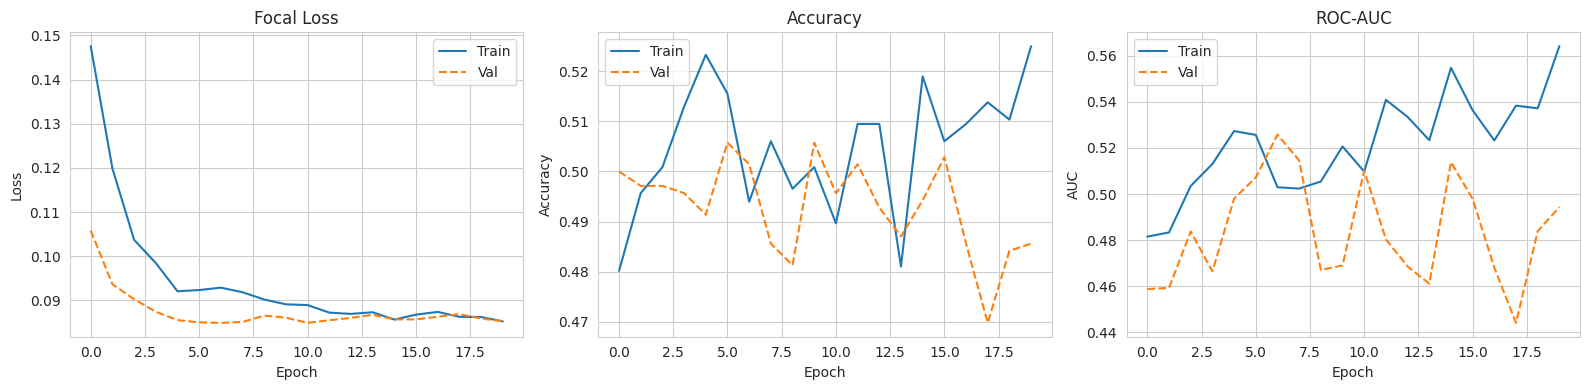

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
metrics = [
    ('loss',     'val_loss',     'Focal Loss', 'Loss'),
    ('accuracy', 'val_accuracy', 'Accuracy',   'Accuracy'),
    ('auc',      'val_auc',      'ROC-AUC',    'AUC'),
]
for ax, (train_key, val_key, title, ylabel) in zip(axes, metrics):
    ax.plot(history.history[train_key], label='Train')
    ax.plot(history.history[val_key],   label='Val', linestyle='--')
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel); ax.legend()
plt.tight_layout()
plt.show()

---
## 9 — Meta-Learner: Rule Score + GRU Blend

In [ ]:
# Optimal GRU threshold on val set (for standalone comparison)
y_val_prob = model.predict(X_val, verbose=0).flatten()
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores_ = [f1_score(y_val, (y_val_prob >= t).astype(int), average='macro') for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores_)]
print(f"Optimal GRU threshold : {best_threshold:.2f}  (val macro F1: {max(f1_scores_):.4f})")

Optimal GRU threshold : 0.47  (val macro F1: 0.5215)


In [ ]:
# GRU probabilities on test set
gru_probs_test = model.predict(X_test, verbose=0).flatten()

# Meta-learner inputs — rs_val / rs_test already aligned from build_windows + split
X_meta_val  = np.column_stack([rs_val,  y_val_prob   ])
X_meta_test = np.column_stack([rs_test, gru_probs_test])

# Logistic meta-learner trained on val only — never touches test
meta = LogisticRegression(C=0.1, random_state=SEED)
meta.fit(X_meta_val, y_val)

rule_coef = meta.coef_[0][0]
gru_coef  = meta.coef_[0][1]
ratio = abs(rule_coef) / (abs(rule_coef) + abs(gru_coef)) * 100
print(f"Meta-learner coefficients:")
print(f"  rule_score : {rule_coef:.4f}")
print(f"  gru_prob   : {gru_coef:.4f}")
print(f"  → Rules {ratio:.0f}%  |  GRU {100-ratio:.0f}%")

Meta-learner coefficients:
  rule_score : 0.4687
  gru_prob   : 0.0280
  → Rules 94%  |  GRU 6%


---
## 10 — Evaluation on Held-Out Test Set

In [ ]:
y_pred_meta = meta.predict(X_meta_test)
y_prob_meta = meta.predict_proba(X_meta_test)[:, 1]

print("\n── Blend (meta-learner) — Test Set ────────────────────────")
print(classification_report(y_test, y_pred_meta, target_names=['Distribution (0)', 'Accumulation (1)']))
print(f"AUC-ROC : {roc_auc_score(y_test, y_prob_meta):.4f}")

gru_pred_standalone  = (gru_probs_test >= best_threshold).astype(int)
rule_pred_standalone = (rs_test >= 0.67).astype(int)

print("\n── Head-to-head comparison ─────────────────────────────────")
print(f"{'System':<22} {'Acc':>6}  {'F1-Dist':>8}  {'F1-Accum':>9}  {'AUC':>7}")
print("-" * 58)
for name, preds, probs in [
    ('Rules only',   rule_pred_standalone, rs_test),
    ('GRU only',     gru_pred_standalone,  gru_probs_test),
    ('Blend (meta)', y_pred_meta,          y_prob_meta),
]:
    acc = accuracy_score(y_test, preds)
    f1d = f1_score(y_test, preds, pos_label=0)
    f1a = f1_score(y_test, preds, pos_label=1)
    auc = roc_auc_score(y_test, probs)
    print(f"{name:<22} {acc*100:>5.1f}%  {f1d:>8.4f}  {f1a:>9.4f}  {auc:>7.4f}")


── Blend (meta-learner) — Test Set ────────────────────────
                  precision    recall  f1-score   support

Distribution (0)       0.59      0.45      0.51       251
Accumulation (1)       0.49      0.62      0.55       213

        accuracy                           0.53       464
       macro avg       0.54      0.54      0.53       464
    weighted avg       0.54      0.53      0.53       464

AUC-ROC : 0.5521

── Head-to-head comparison ─────────────────────────────────
System                    Acc   F1-Dist   F1-Accum      AUC
----------------------------------------------------------
Rules only              55.4%    0.6567     0.3631   0.5540
GRU only                45.9%    0.4508     0.4671   0.4890
Blend (meta)            53.2%    0.5124     0.5507   0.5521


In [ ]:
# Point-biserial correlation: feature vs label
# Note: uses full X (before split) and full y for exploratory analysis only
X_full_norm = minmax_normalize(
    np.concatenate([X_train, X_val, X_test], axis=0), PRICE_IDX
)
y_full = np.concatenate([y_train, y_val, y_test], axis=0)

print(f"{'Feature':<16} {'Correlation':>12} {'p-value':>10}  {'Signal?':>8}")
print("-" * 54)
for col in FEATURE_COLS:
    feature_vals = X_full_norm[:, -1, FEATURE_COLS.index(col)]
    corr, pval   = pointbiserialr(feature_vals, y_full)
    signal       = 'YES' if pval < 0.05 else 'weak' if pval < 0.15 else 'none'
    print(f"{col:<16} {corr:>12.4f} {pval:>10.4f}  {signal:>8}")

Feature           Correlation    p-value   Signal?
------------------------------------------------------
Open                   0.0516     0.0129       YES
High                   0.0521     0.0122       YES
Low                    0.0470     0.0237       YES
Close                  0.0440     0.0343       YES
HH                     0.0257     0.2155      none
AD_slope              -0.0202     0.3315      none
EMA9_ratio             0.0191     0.3576      none
Volume                 0.0388     0.0617      weak
LL                    -0.0487     0.0191       YES


---
## 11 — Confidence Analysis

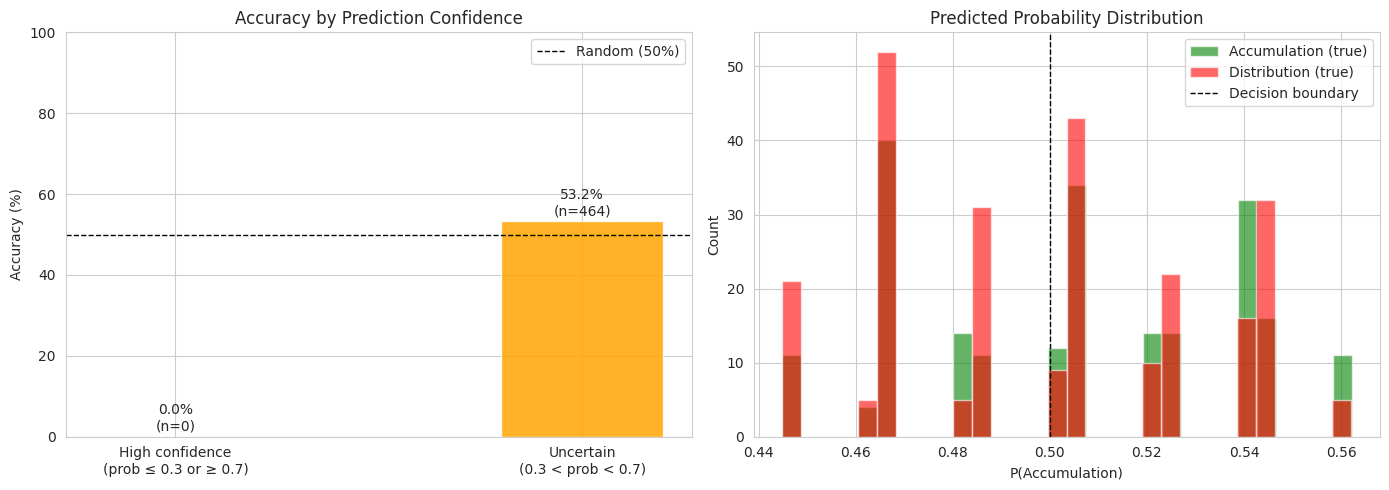

In [ ]:
high_conf = (y_prob_meta >= 0.7) | (y_prob_meta <= 0.3)
uncertain  = ~high_conf

hc_acc = (y_pred_meta[high_conf] == y_test[high_conf]).mean() * 100 if high_conf.sum() > 0 else 0
uc_acc = (y_pred_meta[uncertain] == y_test[uncertain]).mean() * 100 if uncertain.sum()  > 0 else 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels_conf = ['High confidence\n(prob ≤ 0.3 or ≥ 0.7)', 'Uncertain\n(0.3 < prob < 0.7)']
axes[0].bar(labels_conf, [hc_acc, uc_acc], color=['steelblue', 'orange'], alpha=0.85, width=0.4)
axes[0].axhline(50, color='black', linestyle='--', linewidth=1, label='Random (50%)')
axes[0].set_title('Accuracy by Prediction Confidence', fontsize=12)
axes[0].set_ylabel('Accuracy (%)'); axes[0].set_ylim(0, 100); axes[0].legend()
for i, (mask, acc) in enumerate([(high_conf, hc_acc), (uncertain, uc_acc)]):
    axes[0].text(i, acc + 1.5, f'{acc:.1f}%\n(n={mask.sum()})', ha='center', fontsize=10)

axes[1].hist(y_prob_meta[y_test == 1], bins=30, alpha=0.6, color='green',  label='Accumulation (true)')
axes[1].hist(y_prob_meta[y_test == 0], bins=30, alpha=0.6, color='red',    label='Distribution (true)')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1, label='Decision boundary')
axes[1].set_title('Predicted Probability Distribution', fontsize=12)
axes[1].set_xlabel('P(Accumulation)'); axes[1].set_ylabel('Count'); axes[1].legend()

plt.tight_layout()
plt.show()

---
## 12 — Overlay Predictions on Price Chart

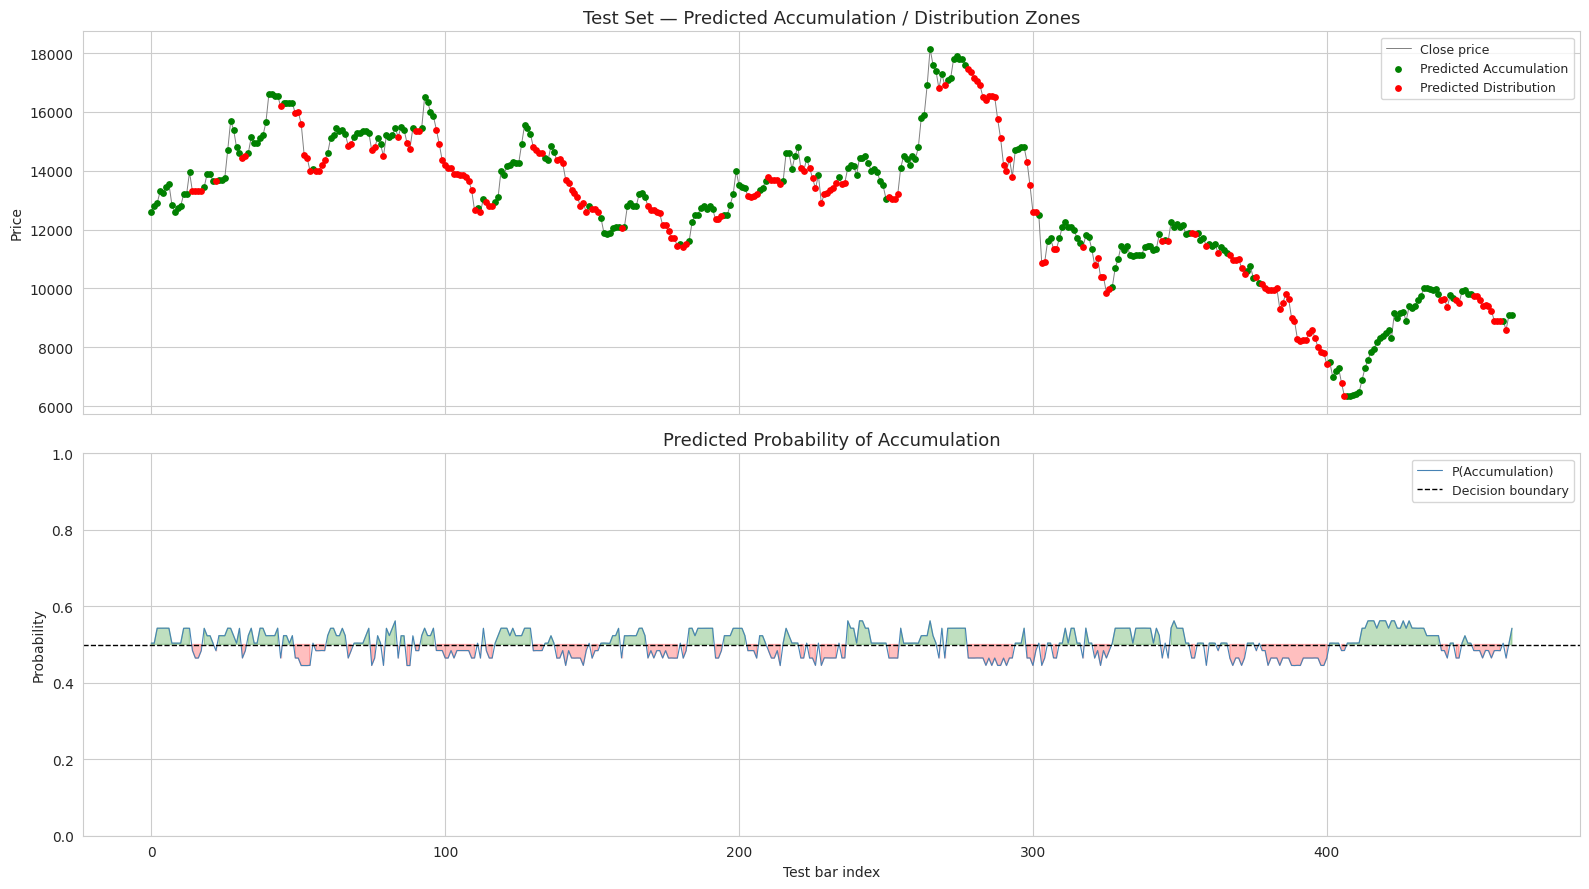

In [ ]:
# Reconstruct test-period rows from labeled (datetime index preserved)
n_train_val = len(X_train) + len(X_val)
test_df = labeled.iloc[WINDOW_SIZE + n_train_val : WINDOW_SIZE + n_train_val + len(y_test)].copy()
test_df = test_df.reset_index(drop=True)
test_df['pred_prob']  = y_prob_meta
test_df['pred_label'] = y_pred_meta

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

axes[0].plot(test_df['Close'], color='gray', linewidth=0.7, label='Close price')
accum_mask = test_df['pred_label'] == 1
dist_mask  = test_df['pred_label'] == 0
axes[0].scatter(test_df.index[accum_mask], test_df.loc[accum_mask, 'Close'],
                color='green', s=15, zorder=5, label='Predicted Accumulation')
axes[0].scatter(test_df.index[dist_mask],  test_df.loc[dist_mask, 'Close'],
                color='red',   s=15, zorder=5, label='Predicted Distribution')
axes[0].set_title('Test Set — Predicted Accumulation / Distribution Zones', fontsize=13)
axes[0].set_ylabel('Price'); axes[0].legend(fontsize=9)

axes[1].plot(test_df['pred_prob'], color='steelblue', linewidth=0.8, label='P(Accumulation)')
axes[1].axhline(0.5, color='black', linestyle='--', linewidth=1, label='Decision boundary')
axes[1].fill_between(test_df.index, test_df['pred_prob'], 0.5,
                     where=test_df['pred_prob'] >= 0.5, alpha=0.25, color='green')
axes[1].fill_between(test_df.index, test_df['pred_prob'], 0.5,
                     where=test_df['pred_prob'] <  0.5, alpha=0.25, color='red')
axes[1].set_title('Predicted Probability of Accumulation', fontsize=13)
axes[1].set_ylabel('Probability'); axes[1].set_xlabel('Test bar index')
axes[1].set_ylim(0, 1); axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 13 — Save Task 3 Artefacts

In [ ]:
model.save('task3_gru_model.keras')
with open('task3_meta_model.pkl', 'wb') as f:
    pickle.dump(meta, f)

print("✓ GRU model saved  → task3_gru_model.keras")
print("✓ Meta-learner saved → task3_meta_model.pkl")

✓ GRU model saved  → task3_gru_model.keras
✓ Meta-learner saved → task3_meta_model.pkl


---
---
# TASK 4 — Portfolio Stock Selection

Apply the trained meta-model to the stock universe. For each stock output:
- **Average return** on buy signals (horizon = 20 bars)
- **Hit rate** — fraction of buy signals where actual forward return > 0
- **Profit factor** — gross wins / gross losses

Select stocks with **hit rate > 52%**, then optimise the portfolio for **maximum Sharpe ratio**.

---
## 14 — Load Stock Universe

In [ ]:
raw_data = {}
for ticker, path in STOCK_UNIVERSE.items():
    if not os.path.isfile(path):
        print(f"  [{ticker}] SKIPPED — file not found: {path}")
        continue
    df = load_csv(path)
    min_rows = WARMUP_ROWS + WINDOW_SIZE + HORIZON_T4 + 50
    if len(df) < min_rows:
        print(f"  [{ticker}] SKIPPED — only {len(df)} rows (need ≥ {min_rows})")
        continue
    raw_data[ticker] = df
    print(f"  [{ticker}] loaded  {len(df):>5} rows")

print(f"\nStocks ready for evaluation: {list(raw_data.keys())}")

  [DHG] loaded   4032 rows
  [DHN] loaded   1215 rows
  [DBT] loaded   3321 rows
  [DCL] loaded   3608 rows
  [DHD] loaded   1457 rows
  [DPH] loaded   1524 rows
  [HDP] loaded   1490 rows
  [BID] loaded   2267 rows
  [VCB] loaded   3413 rows
  [VIB] loaded   1526 rows
  [TCB] loaded   1186 rows

Stocks ready for evaluation: ['DHG', 'DHN', 'DBT', 'DCL', 'DHD', 'DPH', 'HDP', 'BID', 'VCB', 'VIB', 'TCB']


---
## 15 — EDA: Data Quality & Distributions

In [ ]:
eda_rows = []
for ticker, df in raw_data.items():
    ret = df['Close'].pct_change().dropna()
    jb_stat, jb_pval = jarque_bera(ret)
    adf_stat, adf_pval, *_ = adfuller(np.log(df['Close']).diff().dropna(), autolag='AIC')
    eda_rows.append({
        'Ticker'         : ticker,
        'Rows'           : len(df),
        'NullPct'        : df.isnull().mean().mean() * 100,
        'DailyRet_mean%' : ret.mean() * 100,
        'DailyRet_std%'  : ret.std()  * 100,
        'Skewness'       : skew(ret),
        'Kurtosis'       : kurtosis(ret),
        'JB_pval'        : jb_pval,
        'Autocorr_lag1'  : ret.autocorr(1),
        'ADF_pval'       : adf_pval,
        'Stationary'     : adf_pval < 0.05,
    })

eda_df = pd.DataFrame(eda_rows).set_index('Ticker')
pd.set_option('display.float_format', '{:.4f}'.format)
print("=== EDA Summary ===")
print(eda_df.to_string())

=== EDA Summary ===
        Rows  NullPct  DailyRet_mean%  DailyRet_std%  Skewness  Kurtosis  JB_pval  Autocorr_lag1  ADF_pval  Stationary
Ticker                                                                                                                
DHG     4032   0.0000          0.0659         1.9405    0.3103    1.4532   0.0000         0.1206    0.0000        True
DHN     1215   0.0000          0.1592         3.6016    1.3795   43.4338   0.0000        -0.0509    0.0000        True
DBT     3321   0.0000          0.0634         2.8112    0.3907    2.9545   0.0000        -0.0168    0.0000        True
DCL     3608   0.0000          0.0580         2.6608    0.1840    0.9746   0.0000         0.1187    0.0000        True
DHD     1457   0.0000          0.1944         4.8519    0.4419    5.4488   0.0000        -0.1514    0.0000        True
DPH     1524   0.0000          0.1386         4.0224   -0.0140    8.6680   0.0000        -0.1129    0.0000        True
HDP     1490   0.0000       

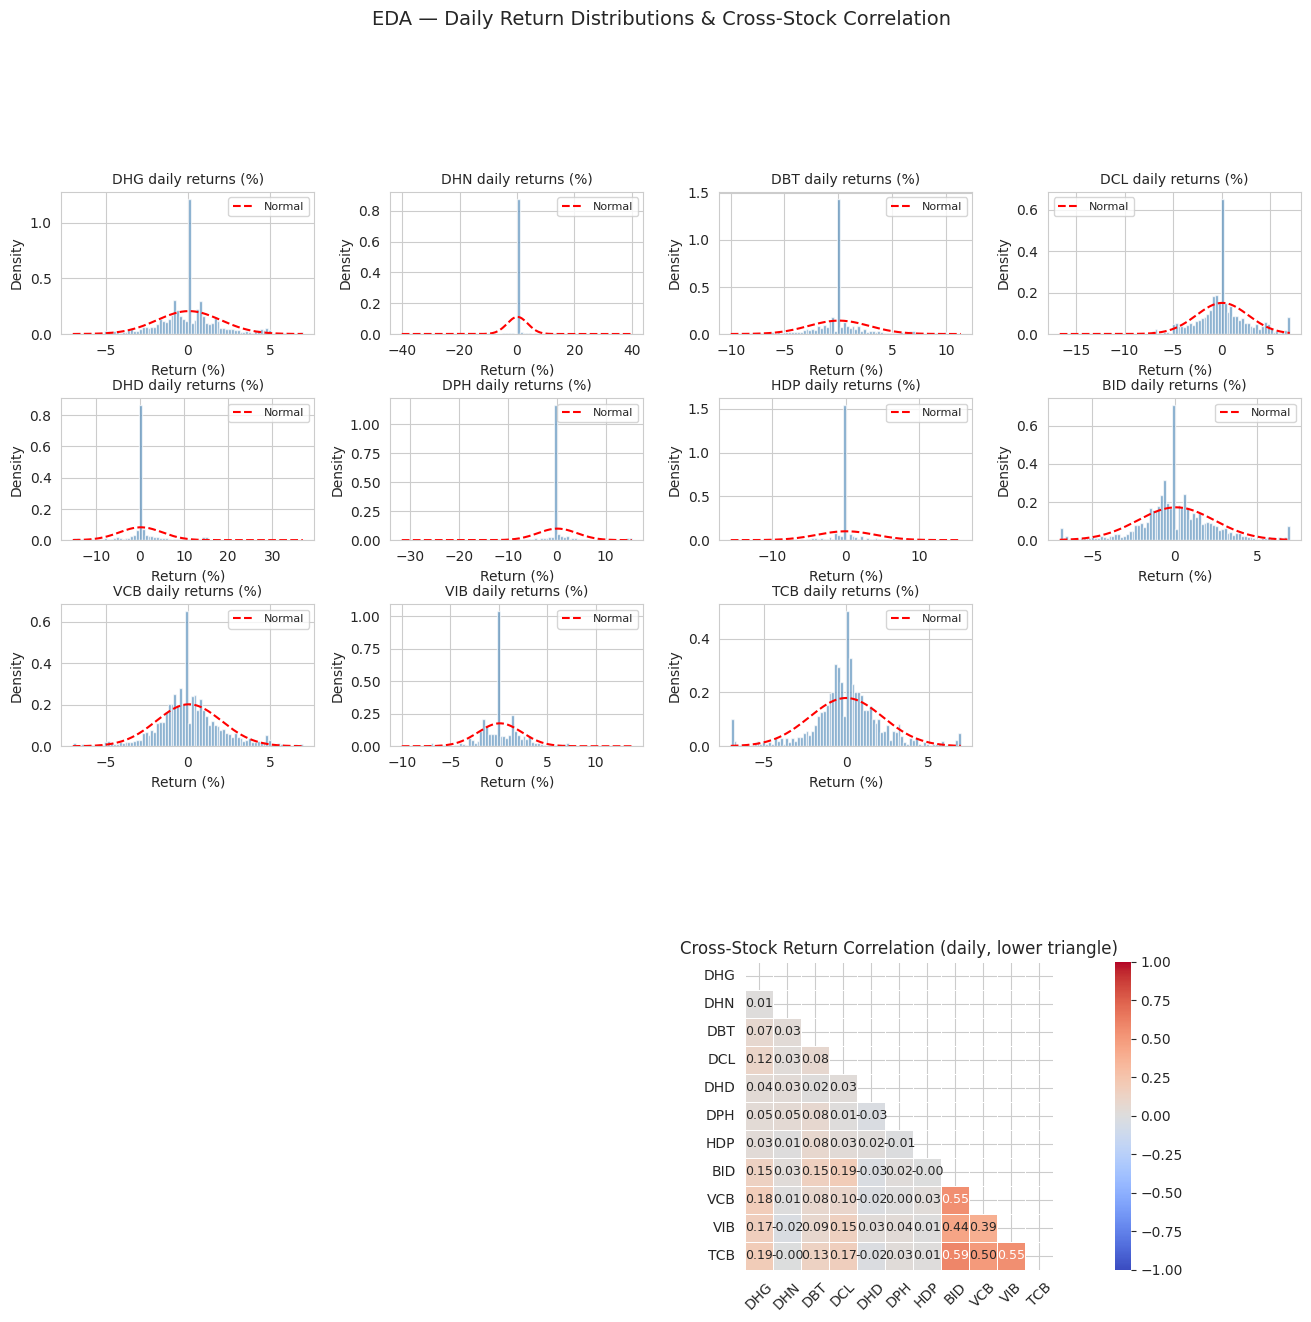


High-correlation pairs (|r| > 0.70) — diversification concern:
  None found.


In [ ]:
tickers    = list(raw_data.keys())
n          = len(tickers)
cols_grid  = min(4, n)
rows_grid  = (n + cols_grid - 1) // cols_grid

# Return distributions + correlation heatmap in one figure
fig = plt.figure(figsize=(cols_grid * 4, rows_grid * 3 + (5 if n > 1 else 0)))

if n > 1:
    gs     = fig.add_gridspec(2, 1, height_ratios=[rows_grid * 3, 5], hspace=0.5)
    gs_top = gs[0].subgridspec(rows_grid, cols_grid, hspace=0.45, wspace=0.3)
else:
    gs     = fig.add_gridspec(1, 1)
    gs_top = gs[0].subgridspec(rows_grid, cols_grid, hspace=0.45, wspace=0.3)

axes_dist = [fig.add_subplot(gs_top[i // cols_grid, i % cols_grid]) for i in range(n)]

for i, ticker in enumerate(tickers):
    ret = raw_data[ticker]['Close'].pct_change().dropna() * 100
    ax  = axes_dist[i]
    ax.hist(ret, bins=80, color='steelblue', alpha=0.7, density=True)
    x = np.linspace(ret.min(), ret.max(), 200)
    ax.plot(x, stats.norm.pdf(x, ret.mean(), ret.std()), 'r--', lw=1.5, label='Normal')
    ax.set_title(f'{ticker} daily returns (%)', fontsize=10)
    ax.set_xlabel('Return (%)'); ax.set_ylabel('Density')
    ax.legend(fontsize=8)

for j in range(n, rows_grid * cols_grid):
    fig.add_subplot(gs_top[j // cols_grid, j % cols_grid]).axis('off')

if n > 1:
    ax_corr = fig.add_subplot(gs[1])
    # Date-aware alignment for correlation
    ret_dict = {t: raw_data[t]['Close'].pct_change().dropna() for t in tickers}
    common_start_eda = max(s.index.min() for s in ret_dict.values())
    common_end_eda   = min(s.index.max() for s in ret_dict.values())
    corr_df  = pd.DataFrame(
        {t: s.loc[common_start_eda:common_end_eda] for t, s in ret_dict.items()}
    ).dropna()
    corr_mat = corr_df.corr()

    mask = np.triu(np.ones_like(corr_mat, dtype=bool))
    sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, vmin=-1, vmax=1, ax=ax_corr,
                annot_kws={'size': 9}, linewidths=0.4, square=True)
    ax_corr.set_title('Cross-Stock Return Correlation (daily, lower triangle)', fontsize=12)
    ax_corr.tick_params(axis='x', rotation=45)
    ax_corr.tick_params(axis='y', rotation=0)
    for i_c in range(len(corr_mat.columns)):
        for j_c in range(i_c + 1, len(corr_mat.columns)):
            if abs(corr_mat.iloc[i_c, j_c]) > 0.7:
                ax_corr.add_patch(plt.Rectangle((j_c, i_c), 1, 1, fill=False,
                                                edgecolor='black', lw=2.5))

plt.suptitle('EDA — Daily Return Distributions & Cross-Stock Correlation',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

if n > 1:
    print("\nHigh-correlation pairs (|r| > 0.70) — diversification concern:")
    found = False
    for i_c in range(len(corr_mat.columns)):
        for j_c in range(i_c + 1, len(corr_mat.columns)):
            if abs(corr_mat.iloc[i_c, j_c]) > 0.7:
                print(f"  {corr_mat.columns[i_c]} × {corr_mat.columns[j_c]} : "
                      f"{corr_mat.iloc[i_c, j_c]:.3f}")
                found = True
    if not found:
        print("  None found.")

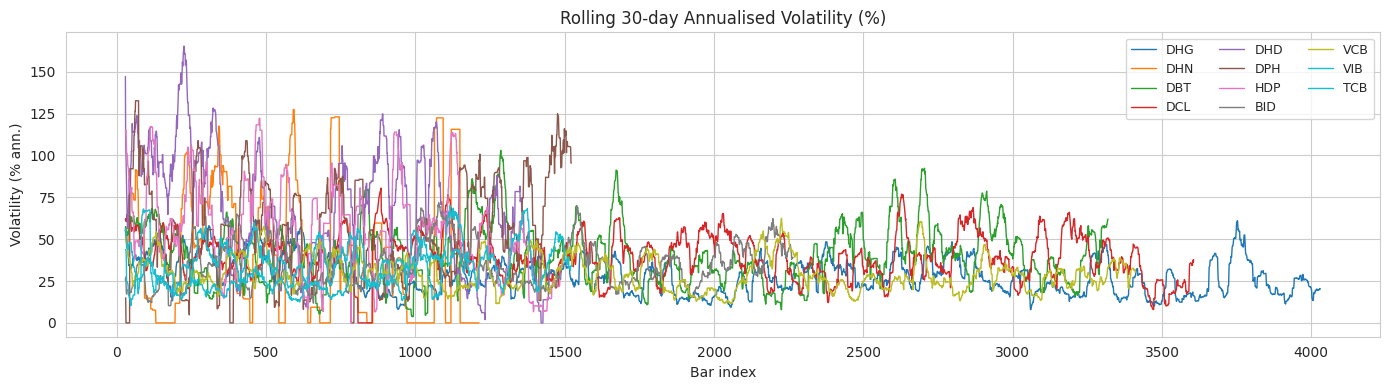

In [ ]:
# Rolling 30-day annualised volatility
fig, ax = plt.subplots(figsize=(14, 4))
colors  = plt.cm.tab10(np.linspace(0, 1, n))
for ticker, col in zip(tickers, colors):
    ret   = raw_data[ticker]['Close'].pct_change().dropna()
    vol30 = ret.rolling(30).std() * np.sqrt(252) * 100
    ax.plot(vol30.reset_index(drop=True).values, color=col, lw=1, label=ticker)
ax.set_title('Rolling 30-day Annualised Volatility (%)', fontsize=12)
ax.set_xlabel('Bar index'); ax.set_ylabel('Volatility (% ann.)')
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

---
## 16 — Cross-Stock Inference (Horizon = 20)

In [ ]:
def evaluate_stock_t4(ticker: str, df_raw: pd.DataFrame) -> dict | None:
    """
    Run the full Task 3 pipeline on one stock and compute T4 metrics.
    build_windows returns aligned (X, y, rule_scores) — no manual slicing needed.
    """
    try:
        lab = engineer_features(df_raw, horizon=HORIZON_T4)
        if len(lab) < WINDOW_SIZE + 50:
            return None

        X_s, y_s, rs_s = build_windows(lab)
        X_s_norm = minmax_normalize(X_s, PRICE_IDX)

        gru_p = model.predict(X_s_norm, verbose=0).flatten()

        # Trim to common length (safety guard)
        min_len = min(len(rs_s), len(gru_p))
        rs_s, gru_p, y_s = rs_s[:min_len], gru_p[:min_len], y_s[:min_len]

        # Meta-model probability
        X_m       = np.column_stack([rs_s, gru_p])
        meta_p    = meta.predict_proba(X_m)[:, 1]
        meta_pred = (meta_p >= 0.5).astype(int)

        # Forward returns aligned to windows
        fwd_rets = lab['fwd_ret'].values[WINDOW_SIZE: WINDOW_SIZE + len(meta_pred)]

        buy_mask = meta_pred == 1
        buy_rets = fwd_rets[buy_mask]
        if len(buy_rets) == 0:
            return None

        wins   = buy_rets[buy_rets > 0].sum()
        losses = abs(buy_rets[buy_rets < 0].sum())

        return {
            'Ticker'        : ticker,
            'N_samples'     : len(X_s),
            'N_buy_signals' : int(buy_mask.sum()),
            'Avg_return_%'  : buy_rets.mean() * 100,
            'Hit_rate'      : float((buy_rets > 0).mean()),
            'Profit_factor' : float(wins / losses) if losses > 0 else np.inf,
            'meta_probs'    : meta_p,
            'fwd_rets'      : fwd_rets,
            'buy_rets'      : buy_rets,
        }
    except Exception as e:
        print(f"  [{ticker}] ERROR: {e}")
        return None


results = {}
for ticker, df_raw in raw_data.items():
    print(f"Evaluating {ticker} ...", end=' ')
    res = evaluate_stock_t4(ticker, df_raw)
    if res:
        results[ticker] = res
        print(f"hit={res['Hit_rate']:.3f}  avg_ret={res['Avg_return_%']:.2f}%  PF={res['Profit_factor']:.2f}")
    else:
        print('SKIPPED')

print(f"\nEvaluated {len(results)} stocks.")

Evaluating DHG ... hit=0.510  avg_ret=1.96%  PF=1.59
Evaluating DHN ... hit=0.624  avg_ret=2.85%  PF=1.55
Evaluating DBT ... hit=0.461  avg_ret=1.24%  PF=1.33
Evaluating DCL ... hit=0.484  avg_ret=3.40%  PF=1.82
Evaluating DHD ... hit=0.472  avg_ret=0.13%  PF=1.03
Evaluating DPH ... hit=0.493  avg_ret=0.62%  PF=1.14
Evaluating HDP ... hit=0.490  avg_ret=0.24%  PF=1.04
Evaluating BID ... hit=0.561  avg_ret=2.71%  PF=1.82
Evaluating VCB ... hit=0.570  avg_ret=2.54%  PF=1.90
Evaluating VIB ... hit=0.622  avg_ret=3.94%  PF=2.22
Evaluating TCB ... hit=0.532  avg_ret=1.63%  PF=1.44

Evaluated 11 stocks.


---
## 17 — Results Table

In [ ]:
summary = pd.DataFrame([
    {
        'Ticker'        : t,
        'N_samples'     : r['N_samples'],
        'N_buy_signals' : r['N_buy_signals'],
        'Avg_return_%'  : round(r['Avg_return_%'], 3),
        'Hit_rate'      : round(r['Hit_rate'], 4),
        'Profit_factor' : round(r['Profit_factor'], 3),
        'Selected'      : r['Hit_rate'] > HIT_RATE_MIN,
    }
    for t, r in results.items()
]).sort_values('Hit_rate', ascending=False).reset_index(drop=True)

print("=" * 82)
print(f"{'Ticker':<8} {'N_smpl':>7} {'N_buy':>6} {'Avg_ret_%':>10} {'Hit_rate':>9} {'Prof_fac':>10} {'Select':>8}")
print("-" * 82)
for _, row in summary.iterrows():
    flag = '✓' if row['Selected'] else '✗'
    print(f"{row['Ticker']:<8} {int(row['N_samples']):>7} {int(row['N_buy_signals']):>6} "
          f"{row['Avg_return_%']:>10.3f} {row['Hit_rate']:>9.4f} {row['Profit_factor']:>10.3f} {flag:>8}")
print("=" * 82)
print(f"Threshold: hit rate > {HIT_RATE_MIN*100:.0f}%  |  Horizon: {HORIZON_T4} bars")

selected = summary[summary['Selected']]
print(f"\nSelected: {list(selected['Ticker'])}  ({len(selected)}/{len(summary)})")

Ticker    N_smpl  N_buy  Avg_ret_%  Hit_rate   Prof_fac   Select
----------------------------------------------------------------------------------
DHN          632    399      2.855    0.6241      1.548        ✓
VIB         1295    923      3.937    0.6219      2.221        ✓
VCB         2816   1874      2.542    0.5704      1.904        ✓
BID         1906   1260      2.710    0.5611      1.817        ✓
TCB          939    600      1.633    0.5317      1.442        ✓
DHG         3163   2171      1.959    0.5104      1.595        ✗
DPH         1231    812      0.619    0.4926      1.142        ✗
HDP         1105    717      0.240    0.4895      1.040        ✗
DCL         3009   1851      3.402    0.4835      1.818        ✗
DHD         1162    835      0.130    0.4719      1.030        ✗
DBT         2633   1706      1.238    0.4607      1.334        ✗
Threshold: hit rate > 52%  |  Horizon: 20 bars

Selected: ['DHN', 'VIB', 'VCB', 'BID', 'TCB']  (5/11)


---
## 18 — Task 4 Visualisations

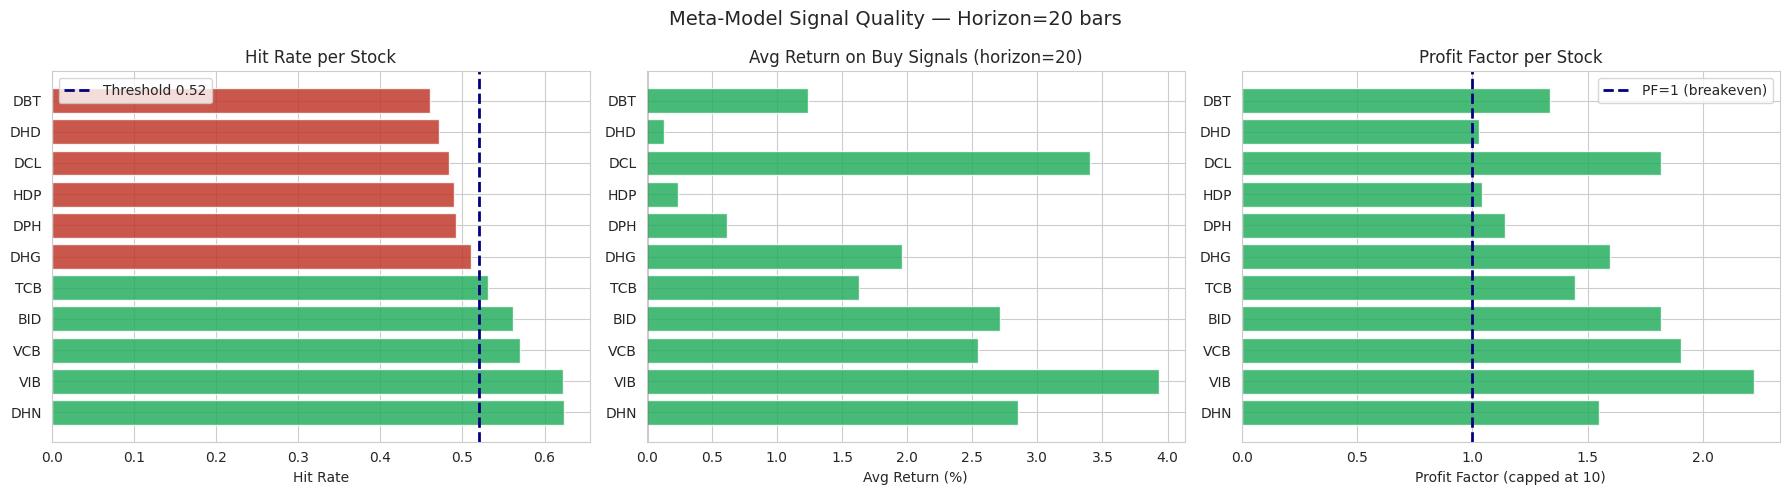

In [ ]:
# Bar chart: hit rate / avg return / profit factor
bar_colors = ['#27ae60' if s else '#c0392b' for s in summary['Selected']]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(summary['Ticker'], summary['Hit_rate'], color=bar_colors, alpha=0.85)
axes[0].axvline(HIT_RATE_MIN, color='navy', linestyle='--', lw=2, label=f'Threshold {HIT_RATE_MIN}')
axes[0].set_title('Hit Rate per Stock', fontsize=12)
axes[0].set_xlabel('Hit Rate'); axes[0].legend()

ret_colors = ['#27ae60' if v > 0 else '#c0392b' for v in summary['Avg_return_%']]
axes[1].barh(summary['Ticker'], summary['Avg_return_%'], color=ret_colors, alpha=0.85)
axes[1].axvline(0, color='black', lw=1)
axes[1].set_title(f'Avg Return on Buy Signals (horizon={HORIZON_T4})', fontsize=12)
axes[1].set_xlabel('Avg Return (%)')

pf_cap    = summary['Profit_factor'].replace(np.inf, 10)
pf_colors = ['#27ae60' if v > 1 else '#c0392b' for v in pf_cap]
axes[2].barh(summary['Ticker'], pf_cap, color=pf_colors, alpha=0.85)
axes[2].axvline(1.0, color='navy', linestyle='--', lw=2, label='PF=1 (breakeven)')
axes[2].set_title('Profit Factor per Stock', fontsize=12)
axes[2].set_xlabel('Profit Factor (capped at 10)'); axes[2].legend()

plt.suptitle(f'Meta-Model Signal Quality — Horizon={HORIZON_T4} bars', fontsize=14)
plt.tight_layout()
plt.show()

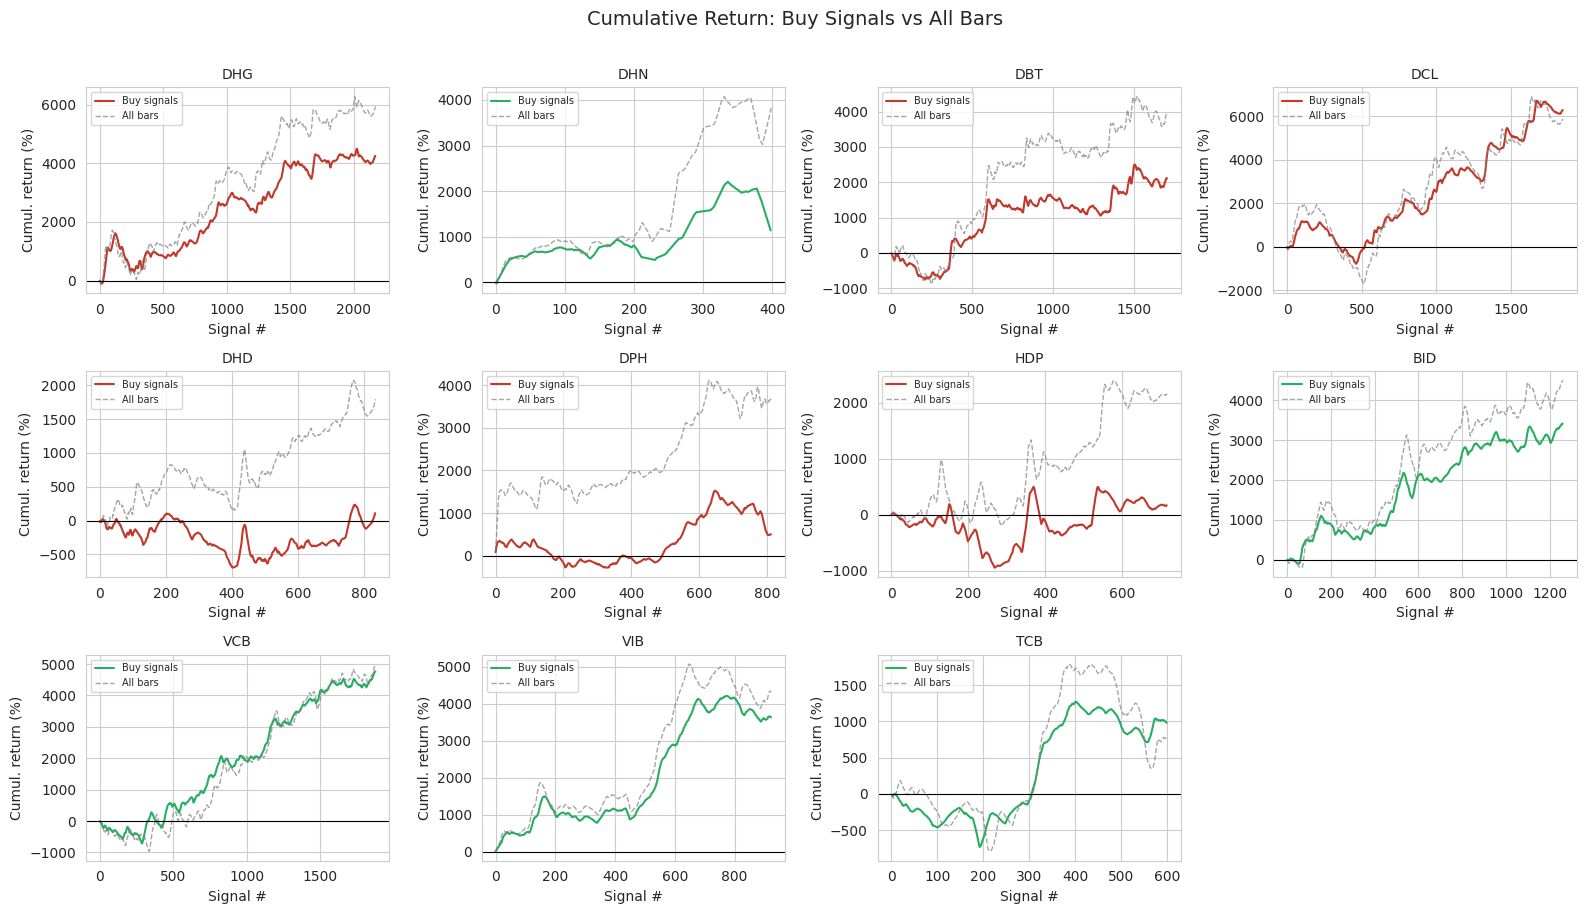

In [ ]:
# Cumulative return: buy signals vs all bars
n_r = len(results)
c_r = min(4, n_r)
r_r = (n_r + c_r - 1) // c_r

fig, axes = plt.subplots(r_r, c_r, figsize=(c_r * 4, r_r * 3))
axes = np.array(axes).flatten()
for i, (ticker, r) in enumerate(results.items()):
    cum_buy = np.cumsum(r['buy_rets']) * 100
    cum_all = np.cumsum(r['fwd_rets']) * 100
    sel = r['Hit_rate'] > HIT_RATE_MIN
    lc  = '#27ae60' if sel else '#c0392b'
    axes[i].plot(cum_buy, color=lc, lw=1.5, label='Buy signals')
    axes[i].plot(np.linspace(0, len(cum_buy), len(cum_all)), cum_all,
                 color='gray', lw=1, linestyle='--', alpha=0.7, label='All bars')
    axes[i].axhline(0, color='black', lw=0.8)
    axes[i].set_title(ticker, fontsize=10)
    axes[i].set_xlabel('Signal #'); axes[i].set_ylabel('Cumul. return (%)')
    axes[i].legend(fontsize=7)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')
plt.suptitle('Cumulative Return: Buy Signals vs All Bars', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 19 — Portfolio Selection Summary

In [ ]:
print("\n" + "═" * 70)
print(f"  PORTFOLIO SELECTION  |  Horizon={HORIZON_T4} bars  |  Hit rate > {HIT_RATE_MIN*100:.0f}%")
print("═" * 70)
print(f"  Evaluated : {len(results)}  |  Selected : {len(selected)}")
print("─" * 70)
print(f"  {'Ticker':<8} {'Hit_rate':>9} {'Avg_ret_%':>10} {'Profit_factor':>14} {'N_signals':>10}")
print("─" * 70)
for _, row in selected.iterrows():
    print(f"  {row['Ticker']:<8} {row['Hit_rate']:>9.4f} {row['Avg_return_%']:>10.3f} "
          f"{row['Profit_factor']:>14.3f} {int(row['N_buy_signals']):>10}")
print("═" * 70)

if len(selected) > 0:
    print(f"\n  Portfolio avg hit rate    : {selected['Hit_rate'].mean()*100:.2f}%")
    print(f"  Portfolio avg return      : {selected['Avg_return_%'].mean():.3f}%")
    print(f"  Portfolio avg prof.factor : {selected['Profit_factor'].mean():.3f}")
else:
    print("\n  No stocks passed the threshold.")


══════════════════════════════════════════════════════════════════════
  PORTFOLIO SELECTION  |  Horizon=20 bars  |  Hit rate > 52%
══════════════════════════════════════════════════════════════════════
  Evaluated : 11  |  Selected : 5
──────────────────────────────────────────────────────────────────────
  Ticker    Hit_rate  Avg_ret_%  Profit_factor  N_signals
──────────────────────────────────────────────────────────────────────
  DHN         0.6241      2.855          1.548        399
  VIB         0.6219      3.937          2.221        923
  VCB         0.5704      2.542          1.904       1874
  BID         0.5611      2.710          1.817       1260
  TCB         0.5317      1.633          1.442        600
══════════════════════════════════════════════════════════════════════

  Portfolio avg hit rate    : 58.18%
  Portfolio avg return      : 2.735%
  Portfolio avg prof.factor : 1.786


---
---
# TASK 4b — Portfolio Optimisation: Maximise Sharpe Ratio

---
## 20 — Build Price Matrix (Date-Aligned)

In [ ]:
# Guard: need at least 2 selected stocks
selected_tickers = list(selected['Ticker'])
if len(selected_tickers) < 2:
    raise ValueError(
        f"Portfolio optimisation requires ≥ 2 selected stocks. "
        f"Currently selected: {selected_tickers}. "
        f"Consider lowering HIT_RATE_MIN or expanding STOCK_UNIVERSE."
    )
print(f"Optimising over {len(selected_tickers)} stocks: {selected_tickers}")

# Align on shared TradingDate (date intersection — no ffill)
price_series = {t: raw_data[t]['Close'] for t in selected_tickers}
common_start = max(s.index.min() for s in price_series.values())
common_end   = min(s.index.max() for s in price_series.values())

print("\nIndividual date ranges:")
for t, s in price_series.items():
    print(f"  {t:<10}  {s.index.min().strftime('%Y-%m-%d')}  →  "
          f"{s.index.max().strftime('%Y-%m-%d')}  ({len(s)} bars)")

print(f"\nShared window  :  {common_start.strftime('%Y-%m-%d')}  →  {common_end.strftime('%Y-%m-%d')}")

price_df = pd.DataFrame(
    {t: s.loc[common_start:common_end] for t, s in price_series.items()}
).dropna()   # inner join — only dates all stocks traded

print(f"Shared bars    :  {len(price_df)}")
print(f"NaN remaining  :  {price_df.isnull().sum().sum()}")
price_df.head()

Optimising over 5 stocks: ['DHN', 'VIB', 'VCB', 'BID', 'TCB']

Individual date ranges:
  DHN         2018-04-19  →  2023-02-28  (1215 bars)
  VIB         2017-01-09  →  2023-02-28  (1526 bars)
  VCB         2009-06-30  →  2023-02-28  (3413 bars)
  BID         2014-01-24  →  2023-02-28  (2267 bars)
  TCB         2018-06-04  →  2023-02-28  (1186 bars)

Shared window  :  2018-06-04  →  2023-02-28
Shared bars    :  1179
NaN remaining  :  0


,DHN,VIB,VCB,BID,TCB
TradingDate,,,,,
2018-06-04,7200.0000,7200.0000,44564.0000,22949.0000,34130.0000
2018-06-05,7200.0000,7400.0000,44038.0000,22874.0000,31997.0000
2018-06-06,7200.0000,7300.0000,44414.0000,23927.0000,30664.0000
2018-06-07,7200.0000,7500.0000,44113.0000,23476.0000,32797.0000
2018-06-08,7200.0000,7400.0000,44865.0000,23701.0000,35063.0000


---
## 21 — Expected Returns & Covariance Estimation

In [ ]:
RISK_FREE_RATE = 0.043   # annualised (e.g. VN 10-yr gov bond ~4-5%)
BARS_PER_YEAR  = 252     # trading days per year
SIGNAL_BLEND   = 0.2     # 20% model signal, 80% historical (conservative — avoids in-sample inflation)

# Base: annualised mean historical return
mu_historical = expected_returns.mean_historical_return(
    price_df, returns_data=False, frequency=BARS_PER_YEAR,
)

# Signal component: annualised avg buy-signal return from T4 evaluation
# Use only the out-of-sample portion to limit in-sample bias
mu_signal = pd.Series({
    t: results[t]['Avg_return_%'] / 100 * (BARS_PER_YEAR / HORIZON_T4)
    for t in selected_tickers
})

mu_blended = (1 - SIGNAL_BLEND) * mu_historical + SIGNAL_BLEND * mu_signal

print("Expected returns comparison:")
print(f"  {'Ticker':<10} {'Historical':>12} {'Signal (ann.)':>14} {'Blended':>10}")
print("-" * 52)
for t in selected_tickers:
    print(f"  {t:<10} {mu_historical[t]:>12.4f} {mu_signal[t]:>14.4f} {mu_blended[t]:>10.4f}")

# Covariance: Ledoit-Wolf shrinkage
S = risk_models.CovarianceShrinkage(price_df, frequency=BARS_PER_YEAR).ledoit_wolf()

print(f"\nCovariance matrix ({S.shape[0]}×{S.shape[1]}, Ledoit-Wolf shrinkage):")
print(pd.DataFrame(S, index=selected_tickers, columns=selected_tickers).round(6).to_string())

Expected returns comparison:
  Ticker       Historical  Signal (ann.)    Blended
----------------------------------------------------
  DHN              0.2711         0.3597     0.2888
  VIB              0.2515         0.4961     0.3004
  VCB              0.1718         0.3202     0.2015
  BID              0.1500         0.3415     0.1883
  TCB             -0.0527         0.2057    -0.0010

Covariance matrix (5×5, Ledoit-Wolf shrinkage):
        DHN     VIB    VCB    BID     TCB
DHN  0.3187 -0.0044 0.0009 0.0054 -0.0003
VIB -0.0044  0.1234 0.0359 0.0548  0.0632
VCB  0.0009  0.0359 0.0853 0.0554  0.0468
BID  0.0054  0.0548 0.0554 0.1440  0.0742
TCB -0.0003  0.0632 0.0468 0.0742  0.1272


---
## 22 — Maximum Sharpe Ratio Optimisation

In [ ]:
ef = EfficientFrontier(mu_blended, S, weight_bounds=(0, 1))
raw_weights   = ef.max_sharpe(risk_free_rate=RISK_FREE_RATE)
clean_weights = ef.clean_weights()

msr_ret, msr_vol, msr_sharpe = ef.portfolio_performance(
    verbose=False, risk_free_rate=RISK_FREE_RATE
)

print("═" * 55)
print("  MAXIMUM SHARPE RATIO PORTFOLIO")
print("═" * 55)
print(f"  {'Ticker':<10} {'Weight':>10}")
print("-" * 25)
for ticker, w in sorted(clean_weights.items(), key=lambda x: -x[1]):
    bar = '█' * int(w * 30)
    print(f"  {ticker:<10} {w:>9.2%}  {bar}")
print("─" * 55)
print(f"  Expected return  : {msr_ret:.2%}  (annualised)")
print(f"  Volatility       : {msr_vol:.2%}  (annualised)")
print(f"  Sharpe ratio     : {msr_sharpe:.4f}")
print(f"  Risk-free rate   : {RISK_FREE_RATE:.2%}")
print("═" * 55)

═══════════════════════════════════════════════════════
  MAXIMUM SHARPE RATIO PORTFOLIO
═══════════════════════════════════════════════════════
  Ticker         Weight
-------------------------
  VIB           48.78%  ██████████████
  VCB           29.69%  ████████
  DHN           21.52%  ██████
  BID            0.00%  
  TCB            0.00%  
───────────────────────────────────────────────────────
  Expected return  : 26.86%  (annualised)
  Volatility       : 24.74%  (annualised)
  Sharpe ratio     : 0.9116
  Risk-free rate   : 4.30%
═══════════════════════════════════════════════════════


---
## 23 — Equal-Weight Benchmark

In [ ]:
n_sel      = len(selected_tickers)
ew_weights = {t: 1 / n_sel for t in selected_tickers}

ef_ew = EfficientFrontier(mu_blended, S, weight_bounds=(0, 1))
ef_ew.set_weights(ew_weights)
ew_ret, ew_vol, ew_sharpe = ef_ew.portfolio_performance(
    verbose=False, risk_free_rate=RISK_FREE_RATE
)

print("EQUAL-WEIGHT BENCHMARK")
print(f"  Expected return  : {ew_ret:.2%}")
print(f"  Volatility       : {ew_vol:.2%}")
print(f"  Sharpe ratio     : {ew_sharpe:.4f}")
print(f"\nSharpe improvement vs equal-weight: {(msr_sharpe/ew_sharpe - 1)*100:+.1f}%")

EQUAL-WEIGHT BENCHMARK
  Expected return  : 19.56%
  Volatility       : 24.18%
  Sharpe ratio     : 0.6311

Sharpe improvement vs equal-weight: +44.4%


---
## 24 — Discrete Allocation

In [ ]:
PORTFOLIO_BUDGET = 100_000_000   # total capital in your currency unit

# Use the most recent price from raw_data (not from price_df which ends at shared_end)
latest_prices = pd.Series(
    {t: raw_data[t]['Close'].iloc[-1] for t in selected_tickers}
)

da = DiscreteAllocation(
    clean_weights,
    latest_prices,
    total_portfolio_value=PORTFOLIO_BUDGET,
)
allocation, leftover = da.greedy_portfolio()

print(f"Portfolio budget : {PORTFOLIO_BUDGET:,.0f}")
print(f"Leftover cash    : {leftover:,.2f}  ({leftover/PORTFOLIO_BUDGET:.2%})\n")
print(f"{'Ticker':<10} {'Shares':>8} {'Price':>10} {'Value':>12} {'Alloc%':>8}")
print("-" * 54)
total_invested = 0
for t, shares in allocation.items():
    price = latest_prices[t]
    value = shares * price
    total_invested += value
    print(f"{t:<10} {shares:>8,} {price:>10.2f} {value:>12,.2f} {value/PORTFOLIO_BUDGET:>8.2%}")
print("-" * 54)
print(f"{'TOTAL':<10} {'':>8} {'':>10} {total_invested:>12,.2f} {total_invested/PORTFOLIO_BUDGET:>8.2%}")

Portfolio budget : 100,000,000
Leftover cash    : 69,950.00  (0.07%)

Ticker       Shares      Price        Value   Alloc%
------------------------------------------------------
VIB           2,373   20550.00 48,765,150.00   48.77%
VCB             317   93500.00 29,639,500.00   29.64%
DHN             974   22100.00 21,525,400.00   21.53%
------------------------------------------------------
TOTAL                          99,930,050.00   99.93%


---
## 25 — Final Portfolio Summary

In [ ]:
print("\n" + "═" * 65)
print("  FINAL PORTFOLIO SUMMARY")
print("═" * 65)
print(f"  Stocks evaluated           : {len(results)}")
print(f"  Stocks passing hit rate    : {len(selected)}  (hit rate > {HIT_RATE_MIN:.0%})")
print(f"  Stocks with non-zero weight: {sum(w > 1e-4 for w in clean_weights.values())}")
print("─" * 65)
print(f"  Optimisation               : Maximum Sharpe Ratio (PyPortfolioOpt)")
print(f"  Expected return method     : {int((1-SIGNAL_BLEND)*100)}% historical + {int(SIGNAL_BLEND*100)}% meta-model signal")
print(f"  Covariance method          : Ledoit-Wolf shrinkage")
print(f"  Risk-free rate             : {RISK_FREE_RATE:.2%}")
print(f"  Bars per year              : {BARS_PER_YEAR}")
print("─" * 65)
print(f"  Portfolio expected return  : {msr_ret:.2%}")
print(f"  Portfolio volatility       : {msr_vol:.2%}")
print(f"  Portfolio Sharpe ratio     : {msr_sharpe:.4f}")
print(f"  Equal-weight Sharpe        : {ew_sharpe:.4f}")
print(f"  Sharpe improvement         : {(msr_sharpe/ew_sharpe - 1)*100:+.1f}%")
print("─" * 65)
print("  Optimal weights:")
for t, w in sorted(clean_weights.items(), key=lambda x: -x[1]):
    if w > 1e-4:
        print(f"    {t:<10} {w:.2%}")
print("═" * 65)


═════════════════════════════════════════════════════════════════
  FINAL PORTFOLIO SUMMARY
═════════════════════════════════════════════════════════════════
  Stocks evaluated           : 11
  Stocks passing hit rate    : 5  (hit rate > 52%)
  Stocks with non-zero weight: 3
─────────────────────────────────────────────────────────────────
  Optimisation               : Maximum Sharpe Ratio (PyPortfolioOpt)
  Expected return method     : 80% historical + 20% meta-model signal
  Covariance method          : Ledoit-Wolf shrinkage
  Risk-free rate             : 4.30%
  Bars per year              : 252
─────────────────────────────────────────────────────────────────
  Portfolio expected return  : 26.86%
  Portfolio volatility       : 24.74%
  Portfolio Sharpe ratio     : 0.9116
  Equal-weight Sharpe        : 0.6311
  Sharpe improvement         : +44.4%
─────────────────────────────────────────────────────────────────
  Optimal weights:
    VIB        48.78%
    VCB        29.69%
    DHN 